# Phase 3a -- FinBERT News Sentiment for Wheat (GDELT 2.0 + FinBERT)

**Goal:** build a daily news-sentiment feature series for 2017-01-01 -> today, using GDELT 2.0 as the headline corpus and FinBERT (`ProsusAI/finbert`) for sentiment scoring. Output is a single CSV that the v2.4.1 ablation notebook will consume as a new static-feature group.

**Window:** GDELT 2.0 has dense English coverage from ~2017+. Earlier dates have sparse ag-themed records, so we restrict to 2017+ and treat this as the **short-window ablation track** (parallel to the Sentinel-2 / Polymarket constraints).

**Features produced (3 columns, daily):**
- `news_sentiment_mean` -- mean of `(pos_prob - neg_prob)` across the day's wheat-related headlines.
- `news_count` -- number of unique headlines per day (proxy for news volume / attention).
- `news_negative_tail_mean` -- mean sentiment of the most-negative quartile of the day's headlines (captures crisis spikes that the simple mean would dilute).

**Reproducibility:**
- GDELT API queries are deterministic for fixed `(query, time-window)` pairs.
- FinBERT inference is deterministic on GPU with fixed seed + cudnn.deterministic.
- All outputs cached to `Drive/Quants/alternative_data/raw/` and `processed/` -- re-running the ablation later does NOT re-hit GDELT or re-run FinBERT.

**Pipeline:**
1. Mount Drive (same path as v2.4.1).
2. Query GDELT 2.0 DocAPI for wheat-relevant headlines, week-by-week, 2017-01-01 -> today.
3. Deduplicate by URL hash; cache raw headlines CSV.
4. Run FinBERT batched inference on each headline (GPU).
5. Aggregate to daily features.
6. Save to `Drive/Quants/alternative_data/processed/finbert_wheat_sentiment_daily.csv`.

**GPU:** Colab T4 is enough. A100 if you want it faster.
**No data upload required** -- everything is pulled live from GDELT.


## 1. Install deps

In [3]:
!pip install -q transformers==4.45.2 sentencepiece tqdm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 106.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 116.6 MB/s eta 0:00:00


## 2. Imports + seeds

In [4]:
import os, time, json, urllib.parse
from datetime import datetime, timedelta
from pathlib import Path
import requests
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
print('Device:', DEVICE)


Device: cuda


## 3. Drive mount + paths

In [5]:
from google.colab import drive
drive.mount('/content/drive')
BASE = Path('/content/drive/MyDrive/Quants ')
ALT_RAW  = BASE / 'alternative_data' / 'raw'
ALT_PROC = BASE / 'alternative_data' / 'processed'
ALT_RAW.mkdir(parents=True, exist_ok=True)
ALT_PROC.mkdir(parents=True, exist_ok=True)

RAW_HEADLINES_CSV  = ALT_RAW  / 'gdelt_wheat_headlines_2017_present.csv'
SCORED_CSV         = ALT_RAW  / 'gdelt_wheat_headlines_finbert_scored.csv'
DAILY_FEATURES_CSV = ALT_PROC / 'finbert_wheat_sentiment_daily.csv'
print('Outputs ->', ALT_PROC)


Mounted at /content/drive
Outputs -> /content/drive/MyDrive/Quants /alternative_data/processed


## 4. Pull GDELT 2.0 headlines (week-by-week)

GDELT 2.0 DocAPI returns up to 250 articles per query. We paginate by 7-day windows. Cached to Drive -- skipped on re-run.


In [12]:
GDELT_URL = 'https://api.gdeltproject.org/api/v2/doc/doc'

QUERY = (
    '("wheat futures" OR "wheat prices" OR "wheat harvest" OR "wheat crop" '
    'OR "wheat exports" OR "wheat shortage" OR "grain market" OR "grain exports" '
    'OR "wheat production" OR "wheat yield" OR "wheat planting") '
    'sourcelang:eng'
)

START_DATE  = datetime(2017, 1, 1)
END_DATE    = datetime.utcnow()
WINDOW_DAYS = 7

def gdelt_pull_window(start, end, max_records=250, retries=3):
    params = {
        'query': QUERY,
        'mode': 'ArtList',
        'format': 'json',
        'maxrecords': max_records,
        'startdatetime': start.strftime('%Y%m%d%H%M%S'),
        'enddatetime':   end.strftime('%Y%m%d%H%M%S'),
        'sort': 'HybridRel',
    }
    url = GDELT_URL + '?' + urllib.parse.urlencode(params)
    for attempt in range(retries):
        try:
            r = requests.get(url, timeout=30)
            if r.status_code == 200:
                try:
                    return r.json().get('articles', [])
                except json.JSONDecodeError:
                    return []
            else:
                time.sleep(2 ** attempt)
        except requests.RequestException:
            time.sleep(2 ** attempt)
    return []

if RAW_HEADLINES_CSV.exists():
    print(f'Cached headlines found at {RAW_HEADLINES_CSV} -- loading.')
    raw_df = pd.read_csv(RAW_HEADLINES_CSV)
    print(f'  {len(raw_df)} headlines')
else:
    print('No cache -- pulling from GDELT (~5-10 min)...')
    rows = []
    cur = START_DATE
    pbar = tqdm(total=(END_DATE - START_DATE).days // WINDOW_DAYS + 1)
    while cur < END_DATE:
        nxt = min(cur + timedelta(days=WINDOW_DAYS), END_DATE)
        articles = gdelt_pull_window(cur, nxt)
        for a in articles:
            rows.append({
                'seendate': a.get('seendate', ''),
                'title':    a.get('title', '').strip(),
                'url':      a.get('url', ''),
                'domain':   a.get('domain', ''),
                'language': a.get('language', ''),
            })
        cur = nxt
        pbar.update(1)
        time.sleep(0.3)
    pbar.close()
    raw_df = pd.DataFrame(rows)
    raw_df.to_csv(RAW_HEADLINES_CSV, index=False)
    print(f'Pulled {len(raw_df)} raw rows -> {RAW_HEADLINES_CSV}')


/tmp/ipykernel_655/2659252355.py:11: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  END_DATE    = datetime.utcnow()


Cached headlines found at /content/drive/MyDrive/Quants /alternative_data/raw/gdelt_wheat_headlines_2017_present.csv -- loading.
  98020 headlines


## 5. Deduplicate + clean

In [14]:
raw_df = pd.read_csv(RAW_HEADLINES_CSV)
print(f'Loaded {len(raw_df)} rows')

Loaded 98020 rows


In [15]:
import os
print('File exists:', RAW_HEADLINES_CSV.exists())
print('File size :', os.path.getsize(RAW_HEADLINES_CSV), 'bytes')
# Force a clean reload
raw_df = pd.read_csv(RAW_HEADLINES_CSV)
print('Columns:', raw_df.columns.tolist())
print('Shape:', raw_df.shape)
raw_df.head(3)

File exists: True
File size : 20052536 bytes
Columns: ['seendate', 'title', 'url', 'domain', 'language']
Shape: (98020, 5)


,seendate,title,url,domain,language
0,20170104T210000Z,Southeast AgNET » Archive UF / IFAS Researcher...,http://southeastagnet.com/2017/01/04/ufifas-re...,southeastagnet.com,English
1,20170105T021500Z,Untitled,http://newswise.com/articles/uf-ifas-researche...,newswise.com,English
2,20170107T111500Z,Untitled,http://www.newswise.com/articles/uf-ifas-resea...,newswise.com,English


In [17]:
raw_df = pd.read_csv(RAW_HEADLINES_CSV)

# Drop missing / too-short / placeholder titles
raw_df = raw_df.dropna(subset=['title', 'url'])
raw_df = raw_df[raw_df['title'].str.len() > 10]
raw_df = raw_df[raw_df['title'].str.lower() != 'untitled']

# Parse seendate (GDELT 2.0 returns ISO 8601: YYYYMMDDTHHMMSSZ)
raw_df['date'] = pd.to_datetime(raw_df['seendate'], format='%Y%m%dT%H%M%SZ', errors='coerce')
raw_df = raw_df.dropna(subset=['date'])

# Dedup: same URL → keep one; same exact title within a day → keep one
raw_df = raw_df.drop_duplicates(subset=['url'])
raw_df['title_norm'] = raw_df['title'].str.lower().str.strip()
raw_df = raw_df.sort_values('date')
raw_df['day'] = raw_df['date'].dt.date
raw_df = raw_df.drop_duplicates(subset=['title_norm', 'day'])

# Coarse irrelevance filter
EXCLUDE_PATTERNS = ['wheat allergy', 'wheat free recipe', 'gluten free',
                    'wheat thins', 'mr wheat', 'mrs wheat']
mask = ~raw_df['title_norm'].apply(lambda s: any(p in s for p in EXCLUDE_PATTERNS))
raw_df = raw_df[mask].reset_index(drop=True)

print(f'After dedup + filter: {len(raw_df)} headlines')
print(f'Date range: {raw_df["date"].min()} .. {raw_df["date"].max()}')
print(f'\nTop domains:\n{raw_df["domain"].value_counts().head(15)}')
print(f'\nDaily headline count summary:\n{raw_df.groupby("day").size().describe()}')

After dedup + filter: 70318 headlines
Date range: 2017-01-01 10:45:00 .. 2026-04-26 01:00:00

Top domains:
domain
agriculture.com                3848
hellenicshippingnews.com       2467
producer.com                   1266
marketscreener.com             1189
farmprogress.com               1168
aginfo.net                     1077
af.reuters.com                  941
tribuneindia.com                893
blackseagrain.net               803
agweb.com                       784
timesofindia.indiatimes.com     734
thenews.com.pk                  728
business-standard.com           725
dawn.com                        709
manitobacooperator.ca           686
Name: count, dtype: int64

Daily headline count summary:
count    3204.000000
mean       21.946941
std        11.533402
min         1.000000
25%        12.000000
50%        21.000000
75%        30.000000
max        77.000000
dtype: float64


## 6. FinBERT inference (batched on GPU)

`ProsusAI/finbert` outputs 3 logits -> softmax -> `[positive, negative, neutral]` probabilities. Net sentiment = `pos - neg`. Headlines truncated to 64 tokens.


In [18]:
if SCORED_CSV.exists():
    print(f'Cached scored headlines found -- loading.')
    scored = pd.read_csv(SCORED_CSV, parse_dates=['date'])
else:
    print('Loading FinBERT model...')
    tokenizer = AutoTokenizer.from_pretrained('ProsusAI/finbert')
    model = AutoModelForSequenceClassification.from_pretrained('ProsusAI/finbert').to(DEVICE)
    model.eval()
    LABEL_POS, LABEL_NEG, LABEL_NEU = 0, 1, 2

    titles = raw_df['title'].astype(str).tolist()
    BATCH = 64
    pos_p, neg_p, neu_p = [], [], []
    for i in tqdm(range(0, len(titles), BATCH), desc='FinBERT'):
        batch = titles[i:i+BATCH]
        enc = tokenizer(batch, padding=True, truncation=True, max_length=64,
                        return_tensors='pt').to(DEVICE)
        with torch.no_grad():
            logits = model(**enc).logits
        probs = torch.softmax(logits, dim=-1).cpu().numpy()
        pos_p.extend(probs[:, LABEL_POS].tolist())
        neg_p.extend(probs[:, LABEL_NEG].tolist())
        neu_p.extend(probs[:, LABEL_NEU].tolist())

    scored = raw_df.copy()
    scored['pos_prob'] = pos_p
    scored['neg_prob'] = neg_p
    scored['neu_prob'] = neu_p
    scored['sentiment'] = scored['pos_prob'] - scored['neg_prob']
    scored.to_csv(SCORED_CSV, index=False)
    print(f'Saved scored headlines -> {SCORED_CSV}')

print(f'Sentiment summary:\n{scored["sentiment"].describe()}')


Loading FinBERT model...


tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

FinBERT:   0%|          | 0/1099 [00:00<?, ?it/s]

Saved scored headlines -> /content/drive/MyDrive/Quants /alternative_data/raw/gdelt_wheat_headlines_finbert_scored.csv
Sentiment summary:
count    70318.000000
mean        -0.063645
std          0.586961
min         -0.969012
25%         -0.629926
50%          0.001201
75%          0.268515
max          0.944028
Name: sentiment, dtype: float64


## 7. Daily aggregation -> 3 features

In [19]:
scored['day'] = pd.to_datetime(scored['date']).dt.normalize()

def neg_tail_mean(s):
    if len(s) == 0: return 0.0
    cutoff = np.quantile(s, 0.25)
    tail = s[s <= cutoff]
    return float(tail.mean()) if len(tail) > 0 else float(s.mean())

agg = scored.groupby('day').agg(
    news_sentiment_mean=('sentiment', 'mean'),
    news_count=('sentiment', 'size'),
    news_negative_tail_mean=('sentiment', neg_tail_mean),
).reset_index().rename(columns={'day': 'date'})

# Reindex to a continuous daily calendar; ffill across no-news days; lag 1 day.
full_idx = pd.date_range(agg['date'].min(), agg['date'].max(), freq='D')
agg = agg.set_index('date').reindex(full_idx)
agg['news_count'] = agg['news_count'].fillna(0).astype(int)
agg[['news_sentiment_mean', 'news_negative_tail_mean']] = \
    agg[['news_sentiment_mean', 'news_negative_tail_mean']].ffill().fillna(0.0)

# 1-day publication lag (predict t using info known at t-1)
agg = agg.shift(1).dropna()
agg.index.name = 'date'
agg.to_csv(DAILY_FEATURES_CSV)
print(f'Saved daily features -> {DAILY_FEATURES_CSV}')
print(agg.tail())
print(f'\nShape: {agg.shape}')
print(f'Date range: {agg.index.min().date()} .. {agg.index.max().date()}')


Saved daily features -> /content/drive/MyDrive/Quants /alternative_data/processed/finbert_wheat_sentiment_daily.csv
            news_sentiment_mean  news_count  news_negative_tail_mean
date                                                                
2026-04-22            -0.215531        20.0                -0.912332
2026-04-23            -0.458963        23.0                -0.939191
2026-04-24            -0.394914        20.0                -0.950308
2026-04-25             0.096154        24.0                -0.805675
2026-04-26            -0.497790         5.0                -0.784627

Shape: (3402, 3)
Date range: 2017-01-02 .. 2026-04-26


## 8. Sanity plot

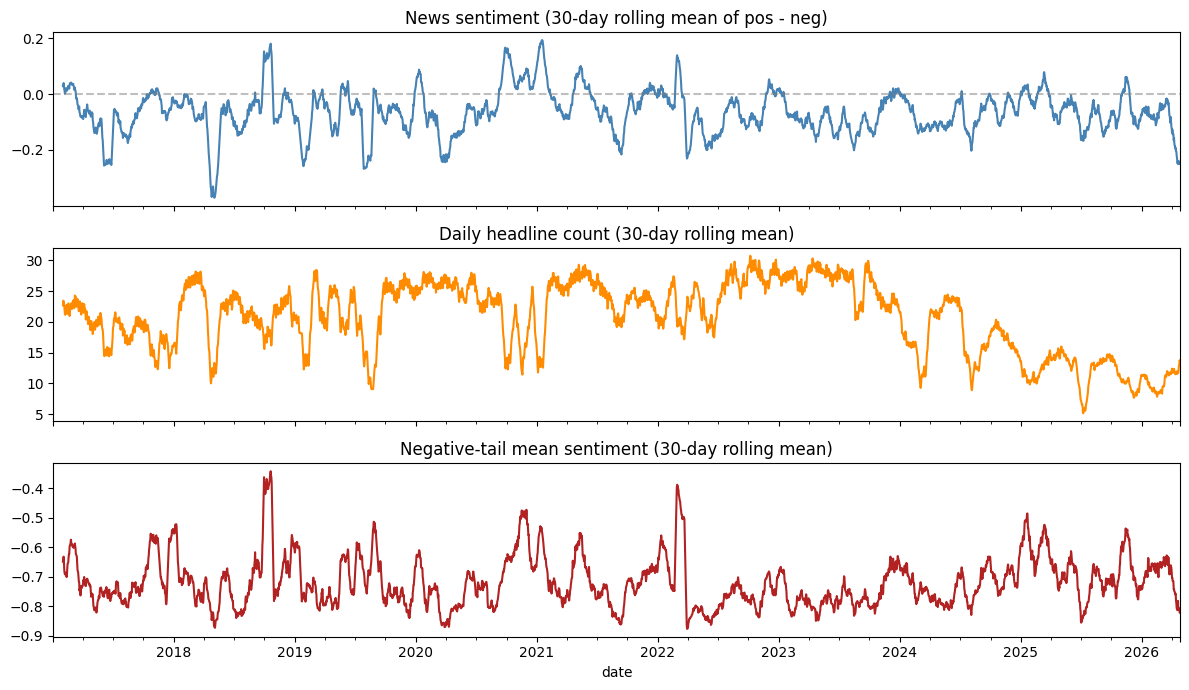


Spot checks (should show sentiment dips / volume spikes):
  2022-02-24: sentiment=+0.745  count=  0  neg_tail=+0.745
  2022-07-22: sentiment=+0.017  count= 16  neg_tail=-0.852
  2023-07-17: sentiment=+0.044  count=  4  neg_tail=-0.034
  2024-08-06: sentiment=+0.279  count= 10  neg_tail=-0.449


In [20]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
agg['news_sentiment_mean'].rolling(30).mean().plot(ax=axes[0], color='steelblue')
axes[0].set_title('News sentiment (30-day rolling mean of pos - neg)')
axes[0].axhline(0, color='gray', ls='--', alpha=0.5)
agg['news_count'].rolling(30).mean().plot(ax=axes[1], color='darkorange')
axes[1].set_title('Daily headline count (30-day rolling mean)')
agg['news_negative_tail_mean'].rolling(30).mean().plot(ax=axes[2], color='firebrick')
axes[2].set_title('Negative-tail mean sentiment (30-day rolling mean)')
axes[2].set_xlabel('date')
plt.tight_layout(); plt.show()

print('\nSpot checks (should show sentiment dips / volume spikes):')
events = ['2022-02-24',  # Russia invades Ukraine
          '2022-07-22',  # Black Sea grain deal
          '2023-07-17',  # Russia exits grain deal
          '2024-08-06']  # Ukrainian incursion into Kursk
for e in events:
    ts = pd.Timestamp(e)
    if ts in agg.index:
        row = agg.loc[ts]
        print(f'  {e}: sentiment={row["news_sentiment_mean"]:+.3f}  '
              f'count={int(row["news_count"]):3d}  neg_tail={row["news_negative_tail_mean"]:+.3f}')


## Done

CSV ready at `Drive/Quants/alternative_data/processed/finbert_wheat_sentiment_daily.csv`.

The next notebook (`phase3_ablation_v241.ipynb`, built after this one runs) will:
1. Reuse the v2.4.1 baseline pipeline verbatim.
2. Read this CSV; align to the daily index used by the classifier.
3. Concatenate the 3 sentiment columns onto the static-feature branch.
4. Run the matched 2017+ baseline + the +FinBERT cell across the 3 deep models.

To re-pull from scratch, delete the cached CSVs in `Drive/Quants/alternative_data/raw/`.
